# Calamity Risk Likelihood Model — Cabuyao, Laguna

**Multi-Source Geospatial Analytics with LSTM Time-Series Prediction**  
_Methodology aligned with thesis reference (Methodology & Figures 4, 7, 8, and 9 in_ `reference.pdf`_.)_

## Pipeline Overview
| Phase | Description | Key Output |
|-------|-------------|------------|
| **Phase 1** | Data Loading & Spatial Aggregation | Monthly barangay-level dataset (hazard, climate, NDVI, population, infrastructure) |
| **Phase 2** | Index Computation (Green, Hazard, Exposure) | Normalized indices per barangay: **Green Index (G)**, **Hazard Index (H)**, **Exposure (E)** |
| **Phase 3** | Calamity Risk Likelihood Derivation | Composite **Calamity Risk Likelihood (CRL)** per barangay and month |
| **Phase 4** | LSTM Model Development | Trained LSTM model for temporal prediction of CRL |
| **Phase 5** | Evaluation & Model Export | Metrics (MAE/RMSE/R²) and saved artifacts for deployment |
| **Phase 6** | Projection & Visualization | Projected CRL (e.g., 2026–2030) and interactive map with year slider (local source) |

## Calamity Risk Likelihood Formula (Paper-Aligned)

Let all components be on a 0–1 scale:
- \(H\) = hazard component (multi-hazard index)
- \(E\) = exposure component (population + infrastructure)
- \(G\) = environmental component (green index; higher means more green space / better condition)

The **Calamity Risk Likelihood (CRL)** follows the weighted normalized scoring method:

\[ \text{CRL} = 0.5 H + 0.3 E + 0.2 (1 - G) \]

- **Hazard (50%)**: multi-hazard severity (flood, landslide, earthquake, typhoon, rainfall)
- **Exposure (30%)**: population and critical infrastructure density
- **Environment (20%)**: lack of green space / environmental buffer (\(1 - G\))

In this notebook:
- Components are first normalized per barangay and time-step.
- CRL is computed on a \([0, 1]\) scale and stored as `calamity_risk_likelihood`.
- The LSTM model is trained to learn temporal patterns of `calamity_risk_likelihood` per barangay using a rolling 6-month window.

> **Note**: For interactive visualization, a separate local source (`build_calamity_risk_data.py` + `calamity_risk_server.py`) converts yearly component indices into **Calamity Risk Likelihood per year (2020–2030)** and serves a Leaflet map with a year slider, mirroring the Hazard Index visualization.

In [1]:
# Calamity Risk Prediction Data Pipeline

#This notebook implements the complete data pipeline for predicting calamity risk likelihood using LSTM neural networks.

## Pipeline Overview:
#1. **Load Raw Data** - Load all CSV files and NDVI numpy arrays
#2. **Data Processing** - Aggregate/broadcast data to barangay level
#3. **Feature Engineering** - Create derived features (green_index, hazard_index, exposure)
#4. **Merge Dataset** - Create unified training dataset
#5. **LSTM Sequences** - Prepare sequences for LSTM model
#6. **Model Training** - Build and train LSTM model

In [2]:
# Cell 1: Import Libraries and Setup

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set base path
BASE_PATH = Path(r'd:\Users\Vince Joseph\Downloads-New\Hazard')

# Define barangay boundaries (approximate bounding boxes for Cabuyao, Laguna)
# These are approximate coordinates for each barangay
BARANGAY_BOUNDS = {
    'Baclaran': {'lat_min': 14.240, 'lat_max': 14.250, 'lon_min': 121.160, 'lon_max': 121.175},
    'Banay-Banay': {'lat_min': 14.250, 'lat_max': 14.260, 'lon_min': 121.125, 'lon_max': 121.140},
    'Banlic': {'lat_min': 14.225, 'lat_max': 14.240, 'lon_min': 121.130, 'lon_max': 121.145},
    'Barangay Dos': {'lat_min': 14.268, 'lat_max': 14.278, 'lon_min': 121.120, 'lon_max': 121.135},
    'Barangay Tres': {'lat_min': 14.275, 'lat_max': 14.285, 'lon_min': 121.115, 'lon_max': 121.130},
    'Barangay Uno': {'lat_min': 14.270, 'lat_max': 14.280, 'lon_min': 121.130, 'lon_max': 121.145},
    'Bigaa': {'lat_min': 14.285, 'lat_max': 14.295, 'lon_min': 121.125, 'lon_max': 121.140},
    'Butong': {'lat_min': 14.285, 'lat_max': 14.295, 'lon_min': 121.130, 'lon_max': 121.145},
    'Casile': {'lat_min': 14.160, 'lat_max': 14.175, 'lon_min': 121.015, 'lon_max': 121.030},
    'Diezmo': {'lat_min': 14.225, 'lat_max': 14.240, 'lon_min': 121.085, 'lon_max': 121.100},
    'Gulod': {'lat_min': 14.255, 'lat_max': 14.265, 'lon_min': 121.160, 'lon_max': 121.175},
    'Mamatid': {'lat_min': 14.230, 'lat_max': 14.245, 'lon_min': 121.150, 'lon_max': 121.165},
    'Marinig': {'lat_min': 14.265, 'lat_max': 14.280, 'lon_min': 121.145, 'lon_max': 121.165},
    'Niugan': {'lat_min': 14.260, 'lat_max': 14.270, 'lon_min': 121.125, 'lon_max': 121.145},
    'Pittland': {'lat_min': 14.225, 'lat_max': 14.240, 'lon_min': 121.100, 'lon_max': 121.115},
    'Pulo': {'lat_min': 14.240, 'lat_max': 14.255, 'lon_min': 121.125, 'lon_max': 121.140},
    'Sala': {'lat_min': 14.268, 'lat_max': 14.278, 'lon_min': 121.120, 'lon_max': 121.130},
    'San Isidro': {'lat_min': 14.235, 'lat_max': 14.250, 'lon_min': 121.135, 'lon_max': 121.150}
}

# List of all barangays
BARANGAYS = list(BARANGAY_BOUNDS.keys())

print(f"Base Path: {BASE_PATH}")
print(f"Number of Barangays: {len(BARANGAYS)}")
print(f"Barangays: {BARANGAYS}")

Base Path: d:\Users\Vince Joseph\Downloads-New\Hazard
Number of Barangays: 18
Barangays: ['Baclaran', 'Banay-Banay', 'Banlic', 'Barangay Dos', 'Barangay Tres', 'Barangay Uno', 'Bigaa', 'Butong', 'Casile', 'Diezmo', 'Gulod', 'Mamatid', 'Marinig', 'Niugan', 'Pittland', 'Pulo', 'Sala', 'San Isidro']


## Step 1: Load Raw Data

Loading all CSV files and NDVI numpy arrays from the data directory.

In [3]:
# Cell 3: Load Raw Data Files

# 1. Load flood susceptibility (point data)
flood_df = pd.read_csv(BASE_PATH / 'flood_susceptibility.csv')
print(f"Flood Susceptibility: {flood_df.shape}")
print(f"  Columns: {list(flood_df.columns)}")

# 2. Load landslide susceptibility (point data)
landslide_df = pd.read_csv(BASE_PATH / 'landslide_susceptibility.csv')
print(f"\nLandslide Susceptibility: {landslide_df.shape}")
print(f"  Columns: {list(landslide_df.columns)}")

# 3. Load weather data (time series - broadcast to all barangays)
weather_df = pd.read_csv(BASE_PATH / 'weather_data.csv')
weather_df['date'] = pd.to_datetime(weather_df['date']).dt.tz_localize(None)
weather_df['date'] = weather_df['date'].dt.to_period('M').dt.to_timestamp()
weather_df = weather_df.rename(columns={
    'Temperature (°C)': 'temp',
    'Humidity (%)': 'humidity',
    'Rainfall (mm)': 'rainfall'
})
print(f"\nWeather Data: {weather_df.shape}")
print(f"  Date range: {weather_df['date'].min()} to {weather_df['date'].max()}")

# 4. Load population data (already per barangay)
population_df = pd.read_csv(BASE_PATH / 'population_barangay.csv')
population_df['Date'] = pd.to_datetime(population_df['Date'])
print(f"\nPopulation Data: {population_df.shape}")
print(f"  Barangays: {[col for col in population_df.columns if col != 'Date' and col != 'Total_Cabuyao']}")

# 5. Load earthquake frequency (time series - broadcast to all barangays)
earthquake_df = pd.read_csv(BASE_PATH / 'earthquake_freq.csv')
earthquake_df['date'] = pd.to_datetime(earthquake_df['date'])
earthquake_df = earthquake_df.rename(columns={
    'max_magnitude': 'earthquake_mag',
    'quake_count': 'earthquake_count'
})
print(f"\nEarthquake Data: {earthquake_df.shape}")
print(f"  Date range: {earthquake_df['date'].min()} to {earthquake_df['date'].max()}")

# 6. Load typhoon frequency (time series - broadcast to all barangays)
typhoon_df = pd.read_csv(BASE_PATH / 'typhoon_freq.csv')
typhoon_df['date'] = pd.to_datetime(typhoon_df['date'])
typhoon_df = typhoon_df.rename(columns={
    'max_severity': 'typhoon_severity'
})
print(f"\nTyphoon Data: {typhoon_df.shape}")
print(f"  Date range: {typhoon_df['date'].min()} to {typhoon_df['date'].max()}")

# 7. Load infrastructure data (point data - count per barangay)
infrastructure_df = pd.read_csv(BASE_PATH / 'infrastructure.csv')
print(f"\nInfrastructure Data: {infrastructure_df.shape}")
print(f"  Categories: {infrastructure_df['category'].unique()}")

# 8. Load NDVI data (numpy arrays - extract mean per date)
ndvi_path = BASE_PATH / 'NDVI_LONG'
ndvi_files = sorted(list(ndvi_path.glob('*.npy')))
print(f"\nNDVI Files: {len(ndvi_files)} files found")
print(f"  Sample files: {[f.name for f in ndvi_files[:3]]}")

Flood Susceptibility: (2000, 3)
  Columns: ['longitude', 'latitude', 'flood_recurrence_pct']

Landslide Susceptibility: (1999, 4)
  Columns: ['longitude', 'latitude', 'slope_degrees', 'elevation_meters']

Weather Data: (72, 4)
  Date range: 2020-01-01 00:00:00 to 2025-12-01 00:00:00

Population Data: (68, 20)
  Barangays: ['Baclaran', 'Banay-Banay', 'Banlic', 'Barangay Dos', 'Barangay Tres', 'Barangay Uno', 'Bigaa', 'Butong', 'Casile', 'Diezmo', 'Gulod', 'Mamatid', 'Marinig', 'Niugan', 'Pittland', 'Pulo', 'Sala', 'San Isidro']

Earthquake Data: (72, 4)
  Date range: 2020-01-31 00:00:00 to 2025-12-31 00:00:00

Typhoon Data: (72, 3)
  Date range: 2020-01-31 00:00:00 to 2025-12-31 00:00:00

Infrastructure Data: (82, 4)
  Categories: <StringArray>
[          'school',         'pharmacy',     'fire_station',
           'police', 'community_centre',           'clinic',
         'hospital',    'sports_centre',          'stadium',
         'townhall']
Length: 10, dtype: str

NDVI Files: 155 fi

## Step 2: Data Processing - Aggregate/Broadcast to Barangay Level

Processing each data source:
- **Flood/Landslide Susceptibility**: Aggregate points to barangay boundaries
- **Weather/Earthquake/Typhoon**: Broadcast to all barangays
- **Infrastructure**: Count facilities per barangay
- **NDVI**: Extract mean values per date

In [4]:
# Cell 5: Helper Functions for Spatial Aggregation

def point_in_barangay(lat, lon, bounds):
    """Check if a point falls within barangay boundaries"""
    return (bounds['lat_min'] <= lat <= bounds['lat_max'] and 
            bounds['lon_min'] <= lon <= bounds['lon_max'])

def assign_barangay(lat, lon):
    """Assign a point to a barangay based on coordinates"""
    for barangay, bounds in BARANGAY_BOUNDS.items():
        if point_in_barangay(lat, lon, bounds):
            return barangay
    return None

def aggregate_to_barangay(df, lat_col, lon_col, value_col, agg_func='mean'):
    """Aggregate point data to barangay level"""
    df['barangay'] = df.apply(lambda row: assign_barangay(row[lat_col], row[lon_col]), axis=1)
    df_with_barangay = df[df['barangay'].notna()]
    
    if agg_func == 'mean':
        aggregated = df_with_barangay.groupby('barangay')[value_col].mean()
    elif agg_func == 'max':
        aggregated = df_with_barangay.groupby('barangay')[value_col].max()
    elif agg_func == 'sum':
        aggregated = df_with_barangay.groupby('barangay')[value_col].sum()
    elif agg_func == 'count':
        aggregated = df_with_barangay.groupby('barangay')[value_col].count()
    
    # Ensure all barangays are present
    result = pd.Series(index=BARANGAYS, dtype=float)
    for brgy in BARANGAYS:
        if brgy in aggregated.index:
            result[brgy] = aggregated[brgy]
        else:
            result[brgy] = 0.0
    
    return result

print("Helper functions defined successfully!")

Helper functions defined successfully!


In [5]:
# Cell 6: Aggregate Flood and Landslide Susceptibility to Barangay Level

# Aggregate flood susceptibility (mean flood recurrence percentage per barangay)
flood_by_barangay = aggregate_to_barangay(
    flood_df, 'latitude', 'longitude', 'flood_recurrence_pct', 'mean'
)
print("=== Flood Susceptibility by Barangay ===")
print(flood_by_barangay.sort_values(ascending=False).head(10))

# Aggregate landslide susceptibility (using slope as proxy - higher slope = higher risk)
landslide_by_barangay = aggregate_to_barangay(
    landslide_df, 'latitude', 'longitude', 'slope_degrees', 'mean'
)
print("\n=== Landslide Susceptibility (Slope) by Barangay ===")
print(landslide_by_barangay.sort_values(ascending=False).head(10))

# Create static susceptibility dataframe
susceptibility_df = pd.DataFrame({
    'barangay': BARANGAYS,
    'flood_susceptibility': [flood_by_barangay[b] for b in BARANGAYS],
    'landslide_susceptibility': [landslide_by_barangay[b] for b in BARANGAYS]
})

print(f"\n=== Susceptibility Summary ===")
print(susceptibility_df.describe())

=== Flood Susceptibility by Barangay ===
Butong           64.428571
Marinig          39.410256
Gulod            25.704545
Baclaran          1.562500
Niugan            0.814815
Banay-Banay       0.000000
Barangay Uno      0.000000
Banlic            0.000000
Barangay Tres     0.000000
Barangay Dos      0.000000
dtype: float64

=== Landslide Susceptibility (Slope) by Barangay ===
Pittland         3.768272
Pulo             2.852337
Barangay Tres    2.841832
San Isidro       2.796857
Mamatid          2.737383
Banlic           2.600856
Bigaa            2.600071
Barangay Uno     2.499326
Niugan           2.465074
Banay-Banay      2.421197
dtype: float64

=== Susceptibility Summary ===
       flood_susceptibility  landslide_susceptibility
count             18.000000                 18.000000
mean               7.328927                  1.966172
std               17.824638                  1.132377
min                0.000000                  0.000000
25%                0.000000                

In [6]:
# Cell 7: Count Infrastructure per Barangay

# Add barangay column to infrastructure
infrastructure_df['barangay'] = infrastructure_df.apply(
    lambda row: assign_barangay(row['latitude'], row['longitude']), axis=1
)

# Count infrastructure per barangay
infra_counts = infrastructure_df[infrastructure_df['barangay'].notna()].groupby('barangay').size()

# Create infrastructure count dictionary
infra_by_barangay = {}
for brgy in BARANGAYS:
    if brgy in infra_counts.index:
        infra_by_barangay[brgy] = infra_counts[brgy]
    else:
        infra_by_barangay[brgy] = 0

print("=== Infrastructure Count by Barangay ===")
for brgy, count in sorted(infra_by_barangay.items(), key=lambda x: x[1], reverse=True):
    print(f"  {brgy}: {count}")

# Add to susceptibility dataframe
susceptibility_df['infra_count'] = susceptibility_df['barangay'].map(infra_by_barangay)

=== Infrastructure Count by Barangay ===
  Barangay Dos: 16
  Banlic: 9
  Niugan: 9
  Pulo: 7
  Banay-Banay: 5
  Casile: 4
  Bigaa: 3
  Diezmo: 3
  Gulod: 3
  Mamatid: 3
  Marinig: 3
  San Isidro: 3
  Baclaran: 2
  Pittland: 2
  Barangay Tres: 1
  Barangay Uno: 0
  Butong: 0
  Sala: 0


In [7]:
# Cell 8: Process NDVI Data - Extract Mean per Date

def extract_date_from_filename(filename):
    """Extract date from NDVI filename (e.g., '2020-01-28_ndvi.npy')"""
    date_str = filename.stem.replace('_ndvi', '')
    return pd.to_datetime(date_str)

def extract_ndvi_values(ndvi_array):
    """
    Extract numeric NDVI values from various array formats.
    Handles structured arrays, object arrays, and regular numeric arrays.
    """
    # If it's a structured array (has field names), extract the data
    if ndvi_array.dtype.names is not None:
        # Try common field names for NDVI data
        for field_name in ndvi_array.dtype.names:
            field_data = ndvi_array[field_name]
            if np.issubdtype(field_data.dtype, np.number):
                return field_data.astype(np.float64)
        # If no numeric field found, try the first field
        first_field = ndvi_array.dtype.names[0]
        return ndvi_array[first_field].astype(np.float64)
    
    # If it's an object array, try to convert to float
    if ndvi_array.dtype == np.object_:
        return ndvi_array.astype(np.float64)
    
    # If it's already a numeric array, just ensure it's float
    if np.issubdtype(ndvi_array.dtype, np.number):
        return ndvi_array.astype(np.float64)
    
    # Try to convert whatever we have to float
    return ndvi_array.astype(np.float64)

def compute_mean_ndvi(ndvi_array):
    """
    Compute mean NDVI from array, handling various data formats.
    NDVI valid range is -1 to 1.
    """
    try:
        # Extract numeric values
        values = extract_ndvi_values(ndvi_array)
        
        # Flatten if multi-dimensional
        values = values.flatten()
        
        # Filter valid NDVI range (-1 to 1)
        valid_mask = (values > -1) & (values <= 1) & np.isfinite(values)
        valid_values = values[valid_mask]
        
        if len(valid_values) == 0:
            # If no valid values in strict range, try broader filter
            valid_mask = np.isfinite(values)
            valid_values = values[valid_mask]
        
        if len(valid_values) > 0:
            return np.nanmean(valid_values)
        return np.nan
    except Exception as e:
        raise ValueError(f"Could not compute mean NDVI: {e}")

# Load all NDVI files and compute mean
ndvi_data = []
errors_count = 0
for npy_file in sorted(ndvi_path.glob('*.npy')):
    try:
        ndvi_array = np.load(npy_file, allow_pickle=True)
        mean_ndvi = compute_mean_ndvi(ndvi_array)
        date = extract_date_from_filename(npy_file)
        ndvi_data.append({'date': date, 'ndvi': mean_ndvi})
    except Exception as e:
        errors_count += 1
        if errors_count <= 3:  # Only show first 3 errors
            print(f"Error loading {npy_file.name}: {e}")

if errors_count > 3:
    print(f"... and {errors_count - 3} more errors")

ndvi_df = pd.DataFrame(ndvi_data)
ndvi_df = ndvi_df.sort_values('date').reset_index(drop=True)

# Handle any NaN values by interpolation
if ndvi_df['ndvi'].isna().any():
    print(f"Note: {ndvi_df['ndvi'].isna().sum()} NaN values will be interpolated")
    ndvi_df['ndvi'] = ndvi_df['ndvi'].interpolate(method='linear')
    ndvi_df['ndvi'] = ndvi_df['ndvi'].bfill().ffill()

print(f"=== NDVI Data Loaded ===")
print(f"Total records: {len(ndvi_df)}")
print(f"Date range: {ndvi_df['date'].min()} to {ndvi_df['date'].max()}")
print(f"NDVI range: {ndvi_df['ndvi'].min():.4f} to {ndvi_df['ndvi'].max():.4f}")
print(f"\nSample NDVI data:")
print(ndvi_df.tail(10))

=== NDVI Data Loaded ===
Total records: 155
Date range: 2000-02-25 00:00:00 to 2025-12-27 00:00:00
NDVI range: 0.0944 to 0.3179

Sample NDVI data:
          date      ndvi
145 2024-04-16  0.136244
146 2024-09-23  0.277567
147 2024-10-18  0.255006
148 2024-12-07  0.213592
149 2025-01-06  0.214194
150 2025-05-01  0.190492
151 2025-06-15  0.249604
152 2025-08-04  0.250402
153 2025-11-07  0.182088
154 2025-12-27  0.276639


In [8]:
# Cell 9: Reshape Population Data from Wide to Long Format

# Melt population data to long format
pop_cols = [col for col in population_df.columns if col not in ['Date', 'Total_Cabuyao']]

# Rename columns to match our barangay names (handle special characters)
column_mapping = {
    'Baclaran': 'Baclaran',
    'Banay-Banay': 'Banay-Banay',
    'Banlic': 'Banlic',
    'Barangay Dos': 'Barangay Dos',
    'Barangay Tres': 'Barangay Tres',
    'Barangay Uno': 'Barangay Uno',
    'Bigaa': 'Bigaa',
    'Butong': 'Butong',
    'Casile': 'Casile',
    'Diezmo': 'Diezmo',
    'Gulod': 'Gulod',
    'Mamatid': 'Mamatid',
    'Marinig': 'Marinig',
    'Niugan': 'Niugan',
    'Pittland': 'Pittland',
    'Pulo': 'Pulo',
    'Sala': 'Sala',
    'San Isidro': 'San Isidro'
}

# Melt the dataframe
population_long = population_df.melt(
    id_vars=['Date'],
    value_vars=pop_cols,
    var_name='barangay',
    value_name='population'
)
population_long = population_long.rename(columns={'Date': 'date'})

print(f"=== Population Data Reshaped ===")
print(f"Shape: {population_long.shape}")
print(f"Date range: {population_long['date'].min()} to {population_long['date'].max()}")
print(f"Barangays: {population_long['barangay'].unique()}")
print(f"\nSample data:")
print(population_long.head(10))

=== Population Data Reshaped ===
Shape: (1224, 3)
Date range: 2020-05-31 00:00:00 to 2025-12-31 00:00:00
Barangays: <StringArray>
[     'Baclaran',   'Banay-Banay',        'Banlic',  'Barangay Dos',
 'Barangay Tres',  'Barangay Uno',         'Bigaa',        'Butong',
        'Casile',        'Diezmo',         'Gulod',       'Mamatid',
       'Marinig',        'Niugan',      'Pittland',          'Pulo',
          'Sala',    'San Isidro']
Length: 18, dtype: str

Sample data:
        date  barangay  population
0 2020-05-31  Baclaran       14601
1 2020-06-30  Baclaran       14597
2 2020-07-31  Baclaran       14593
3 2020-08-31  Baclaran       14589
4 2020-09-30  Baclaran       14585
5 2020-10-31  Baclaran       14581
6 2020-11-30  Baclaran       14576
7 2020-12-31  Baclaran       14572
8 2021-01-31  Baclaran       14568
9 2021-02-28  Baclaran       14564


## Step 3: Merge All Data Sources into Training Dataset

Creating unified training dataset with:
- date | barangay | temp | humidity | rainfall | population
- flood_susceptibility | landslide_susceptibility | ndvi
- earthquake_mag | typhoon_severity | infra_count
- Derived features: green_index | hazard_index | exposure
- Target: calamity_risk_likelihood

In [9]:
# Cell 11: Create Base Dataset - Cross Join of Dates and Barangays

# Get common date range (using weather data as base since it has monthly data)
# Filter to dates where we have population data (May 2020 onwards)
date_range = weather_df[weather_df['date'] >= '2020-05-01']['date'].unique()

print(f"Date range for training: {min(date_range)} to {max(date_range)}")
print(f"Number of time periods: {len(date_range)}")
print(f"Number of barangays: {len(BARANGAYS)}")

# Create base dataframe with all date-barangay combinations
base_records = []
for date in date_range:
    for barangay in BARANGAYS:
        base_records.append({'date': date, 'barangay': barangay})

merged_df = pd.DataFrame(base_records)
merged_df['date'] = pd.to_datetime(merged_df['date'])

print(f"\nBase dataset shape: {merged_df.shape}")
print(f"Total records: {len(date_range)} dates × {len(BARANGAYS)} barangays = {len(date_range) * len(BARANGAYS)}")

Date range for training: 2020-05-01 00:00:00 to 2025-12-01 00:00:00
Number of time periods: 68
Number of barangays: 18

Base dataset shape: (1224, 2)
Total records: 68 dates × 18 barangays = 1224


In [10]:
# Cell 12: Merge All Data Sources

# 1. Merge weather data (broadcast to all barangays)
merged_df = merged_df.merge(
    weather_df[['date', 'temp', 'humidity', 'rainfall']], 
    on='date', 
    how='left'
)
print(f"After weather merge: {merged_df.shape}")

# 2. Merge population data
merged_df = merged_df.merge(
    population_long[['date', 'barangay', 'population']], 
    on=['date', 'barangay'], 
    how='left'
)
print(f"After population merge: {merged_df.shape}")

# 3. Merge static susceptibility data (flood, landslide, infrastructure count)
merged_df = merged_df.merge(
    susceptibility_df[['barangay', 'flood_susceptibility', 'landslide_susceptibility', 'infra_count']], 
    on='barangay', 
    how='left'
)
print(f"After susceptibility merge: {merged_df.shape}")

# 4. Merge earthquake data (broadcast to all barangays)
merged_df = merged_df.merge(
    earthquake_df[['date', 'earthquake_mag', 'earthquake_count']], 
    on='date', 
    how='left'
)
print(f"After earthquake merge: {merged_df.shape}")

# 5. Merge typhoon data (broadcast to all barangays)
merged_df = merged_df.merge(
    typhoon_df[['date', 'typhoon_severity', 'typhoon_count']], 
    on='date', 
    how='left'
)
print(f"After typhoon merge: {merged_df.shape}")

# 6. Merge NDVI data - resample to monthly and merge
# For dates without NDVI, use nearest available or interpolate
ndvi_monthly = ndvi_df.copy()
ndvi_monthly['date'] = ndvi_monthly['date'].dt.to_period('M').dt.to_timestamp()
ndvi_monthly = ndvi_monthly.groupby('date')['ndvi'].mean().reset_index()

# Create a full monthly index and interpolate NDVI
full_date_range = pd.date_range(start='2020-05-01', end='2025-12-31', freq='MS')
ndvi_full = pd.DataFrame({'date': full_date_range})
ndvi_full = ndvi_full.merge(ndvi_monthly, on='date', how='left')
ndvi_full['ndvi'] = ndvi_full['ndvi'].interpolate(method='linear')
ndvi_full['ndvi'] = ndvi_full['ndvi'].bfill().ffill()

merged_df = merged_df.merge(ndvi_full, on='date', how='left')
print(f"After NDVI merge: {merged_df.shape}")

print(f"\n=== Merged Dataset Columns ===")
print(list(merged_df.columns))

After weather merge: (1224, 5)
After population merge: (1224, 6)
After susceptibility merge: (1224, 9)
After earthquake merge: (1224, 11)
After typhoon merge: (1224, 13)
After NDVI merge: (1224, 14)

=== Merged Dataset Columns ===
['date', 'barangay', 'temp', 'humidity', 'rainfall', 'population', 'flood_susceptibility', 'landslide_susceptibility', 'infra_count', 'earthquake_mag', 'earthquake_count', 'typhoon_severity', 'typhoon_count', 'ndvi']


In [11]:
# Cell 13: Feature Engineering - Create Derived Features

def normalize(series):
    """Normalize a series to 0-100 scale"""
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series([50.0] * len(series), index=series.index)
    return ((series - min_val) / (max_val - min_val)) * 100

# Handle Missing Values
# Forward fill then backward fill for time-series data
time_series_cols = ['ndvi', 'earthquake_mag', 'earthquake_count', 'typhoon_severity', 'typhoon_count']
for col in time_series_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df.groupby('barangay')[col].transform(
            lambda x: x.ffill().bfill()
        )

# Fill remaining NaN with 0 or median
merged_df = merged_df.fillna(0)

print("=== Data After Filling NaN ===")
print(merged_df.isnull().sum())

# Calculate Derived Features
# 1. Green Index: Higher NDVI = more vegetation = better
merged_df['green_index'] = ((merged_df['ndvi'] + 1) / 2) * 100

# 2. Hazard Index: Combined risk from multiple hazards (normalized weighted sum)
merged_df['hazard_index'] = (
    normalize(merged_df['flood_susceptibility']) * 0.25 +
    normalize(merged_df['landslide_susceptibility']) * 0.20 +
    normalize(merged_df['earthquake_mag'].replace(0, 0.1)) * 0.20 +
    normalize(merged_df['typhoon_severity'].replace(0, 0.1)) * 0.20 +
    normalize(merged_df['rainfall']) * 0.15
)

# 3. Exposure Index: Population and infrastructure density
merged_df['exposure'] = (
    normalize(merged_df['population']) * 0.6 +
    normalize(merged_df['infra_count']) * 0.4
)

# 4. Target: Calamity Risk Likelihood (0-1 scale)
merged_df['calamity_risk_likelihood'] = normalize(
    merged_df['hazard_index'] * 0.5 +
    merged_df['exposure'] * 0.3 +
    (100 - merged_df['green_index']) * 0.2
) / 100  # Scale to 0-1

print("\n=== Derived Features Statistics ===")
print(merged_df[['green_index', 'hazard_index', 'exposure', 'calamity_risk_likelihood']].describe())

=== Data After Filling NaN ===
date                        0
barangay                    0
temp                        0
humidity                    0
rainfall                    0
population                  0
flood_susceptibility        0
landslide_susceptibility    0
infra_count                 0
earthquake_mag              0
earthquake_count            0
typhoon_severity            0
typhoon_count               0
ndvi                        0
dtype: int64

=== Derived Features Statistics ===
       green_index  hazard_index     exposure  calamity_risk_likelihood
count  1224.000000   1224.000000  1224.000000               1224.000000
mean     61.332629     38.777263    40.138889                  0.486711
std       1.944445      8.215720     9.774706                  0.186521
min      56.812210     20.000000    30.000000                  0.000000
25%      60.012679     34.528051    35.000000                  0.380548
50%      61.304092     39.264277    37.500000                  0.50

In [12]:
# Cell 14: Finalize and Save Training Dataset

# Sort by date and barangay
merged_df = merged_df.sort_values(['date', 'barangay']).reset_index(drop=True)

# Select final columns for the training dataset
final_columns = [
    'date', 'barangay', 'temp', 'humidity', 'rainfall', 'population',
    'flood_susceptibility', 'landslide_susceptibility', 'ndvi',
    'earthquake_mag', 'typhoon_severity', 'infra_count',
    'green_index', 'hazard_index', 'exposure', 'calamity_risk_likelihood'
]

training_df = merged_df[final_columns].copy()

# Save to CSV
training_df.to_csv(BASE_PATH / 'lstm_training_data.csv', index=False)

print(f"=== Training Dataset Saved ===")
print(f"Shape: {training_df.shape}")
print(f"Date range: {training_df['date'].min()} to {training_df['date'].max()}")
print(f"Barangays: {training_df['barangay'].nunique()}")
print(f"\n=== Column Summary ===")
print(training_df.dtypes)
print(f"\n=== Sample Data (First 20 rows) ===")
training_df.head(20)

=== Training Dataset Saved ===
Shape: (1224, 16)
Date range: 2020-05-01 00:00:00 to 2025-12-01 00:00:00
Barangays: 18

=== Column Summary ===
date                        datetime64[us]
barangay                               str
temp                               float64
humidity                           float64
rainfall                           float64
population                         float64
flood_susceptibility               float64
landslide_susceptibility           float64
ndvi                               float64
earthquake_mag                     float64
typhoon_severity                   float64
infra_count                          int64
green_index                        float64
hazard_index                       float64
exposure                           float64
calamity_risk_likelihood           float64
dtype: object

=== Sample Data (First 20 rows) ===


,date,barangay,temp,humidity,rainfall,population,flood_susceptibility,landslide_susceptibility,ndvi,earthquake_mag,typhoon_severity,infra_count,green_index,hazard_index,exposure,calamity_risk_likelihood
0,2020-05-01,Baclaran,28.912432,78.698540,259.3,0.0,1.562500,2.087027,0.184999,0.0,0.0,2,59.249958,39.502079,35.0,0.457761
1,2020-05-01,Banay-Banay,28.912432,78.698540,259.3,0.0,0.000000,2.421197,0.184999,0.0,0.0,5,59.249958,40.669389,42.5,0.565316
2,2020-05-01,Banlic,28.912432,78.698540,259.3,0.0,0.000000,2.600856,0.184999,0.0,0.0,9,59.249958,41.622921,52.5,0.697280
3,2020-05-01,Barangay Dos,28.912432,78.698540,259.3,0.0,0.000000,2.298231,0.184999,0.0,0.0,16,59.249958,40.016751,70.0,0.866067
4,2020-05-01,Barangay Tres,28.912432,78.698540,259.3,0.0,0.000000,2.841832,0.184999,0.0,0.0,1,59.249958,42.901896,32.5,0.493816
5,2020-05-01,Barangay Uno,28.912432,78.698540,259.3,0.0,0.000000,2.499326,0.184999,0.0,0.0,0,59.249958,41.084054,30.0,0.430850
6,2020-05-01,Bigaa,28.912432,78.698540,259.3,0.0,0.000000,2.600071,0.184999,0.0,0.0,3,59.249958,41.618759,37.5,0.526399
7,2020-05-01,Butong,28.912432,78.698540,259.3,0.0,64.428571,0.624417,0.184999,0.0,0.0,0,59.249958,56.133026,30.0,0.716450
8,2020-05-01,Casile,28.912432,78.698540,259.3,0.0,0.000000,0.000000,0.184999,0.0,0.0,4,59.249958,27.818951,40.0,0.292973
9,2020-05-01,Diezmo,28.912432,78.698540,259.3,0.0,0.000000,0.000000,0.184999,0.0,0.0,3,59.249958,27.818951,37.5,0.264506


## Step 4: Prepare LSTM Sequences

Input: 6 months of historical features  
Output: Calamity Risk Likelihood for next month  
Shape: (samples, 6, 12) → (samples, 1)

In [13]:
# Cell 11: Prepare LSTM Sequences

from sklearn.preprocessing import MinMaxScaler

# Define feature columns (excluding date, barangay, and target)
feature_cols = [
    'temp', 'humidity', 'rainfall', 'population',
    'flood_susceptibility', 'landslide_susceptibility', 'ndvi',
    'earthquake_mag', 'typhoon_severity', 'infra_count',
    'green_index', 'hazard_index'
]

target_col = 'calamity_risk_likelihood'
sequence_length = 6  # 6 months of historical data

def create_sequences(df, feature_cols, target_col, seq_length):
    """
    Create sequences for LSTM training.
    For each barangay, create sequences of seq_length months to predict next month's risk.
    """
    X_list = []
    y_list = []
    barangay_list = []
    date_list = []
    
    # Scale features
    scaler = MinMaxScaler()
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])
    
    # Target scaler
    target_scaler = MinMaxScaler()
    df_scaled[target_col] = target_scaler.fit_transform(df[[target_col]])
    
    for barangay in df['barangay'].unique():
        barangay_data = df_scaled[df_scaled['barangay'] == barangay].sort_values('date')
        
        if len(barangay_data) < seq_length + 1:
            continue
            
        features = barangay_data[feature_cols].values
        targets = barangay_data[target_col].values
        dates = barangay_data['date'].values
        
        for i in range(len(features) - seq_length):
            X_list.append(features[i:i+seq_length])
            y_list.append(targets[i+seq_length])
            barangay_list.append(barangay)
            date_list.append(dates[i+seq_length])
    
    X = np.array(X_list)
    y = np.array(y_list)
    
    return X, y, barangay_list, date_list, scaler, target_scaler

# Create sequences
X, y, barangays_seq, dates_seq, feature_scaler, target_scaler = create_sequences(
    training_df, feature_cols, target_col, sequence_length
)

print(f"=== LSTM Sequences Created ===")
print(f"X shape: {X.shape} (samples, timesteps, features)")
print(f"y shape: {y.shape} (samples,)")
print(f"Number of features: {len(feature_cols)}")
print(f"Sequence length: {sequence_length} months")

=== LSTM Sequences Created ===
X shape: (1116, 6, 12) (samples, timesteps, features)
y shape: (1116,) (samples,)
Number of features: 12
Sequence length: 6 months


In [14]:
# Cell 12: Train-Test-Validation Split

# Use temporal split to avoid data leakage: 64% train, 16% validation, 20% test
train_end = int(len(X) * 0.64)
val_end = int(len(X) * 0.80)

X_train = X[:train_end]
X_val = X[train_end:val_end]
X_test = X[val_end:]

y_train = y[:train_end]
y_val = y[train_end:val_end]
y_test = y[val_end:]

print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")

Training set:   X=(714, 6, 12), y=(714,)
Validation set: X=(178, 6, 12), y=(178,)
Test set:       X=(224, 6, 12), y=(224,)


## Step 5: Build and Train LSTM Model

Architecture: LSTM(64) → Dropout → LSTM(32) → Dropout → Dense(16) → Dense(1)  
Loss: MSE | Metrics: MAE, RMSE, R²

In [15]:
# Cell: Build and Train LSTM Model
# Architecture: LSTM(64) → Dropout → LSTM(32) → Dropout → Dense(16) → Dense(1)
# Loss: MSE | Metrics: MAE, RMSE, R²

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Custom metrics: RMSE and R²
def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

def r_squared(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - (ss_res / (ss_tot + tf.keras.backend.epsilon()))

# Build model
n_timesteps = X_train.shape[1]   # 6
n_features = X_train.shape[2]    # 12

lstm_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(n_timesteps, n_features)),
    Dropout(0.3),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', rmse, r_squared]
)

lstm_model.summary()

# Train with early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 64)          │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0854 - mae: 0.2324 - r_squared: -83.8498 - rmse: 0.2863 - val_loss: 0.0340 - val_mae: 0.1596 - val_r_squared: -172.5509 - val_rmse: 0.1773
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0303 - mae: 0.1388 - r_squared: -46.7260 - rmse: 0.2225 - val_loss: 0.0117 - val_mae: 0.0856 - val_r_squared: -60.1032 - val_rmse: 0.1087
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0142 - mae: 0.0942 - r_squared: -50.1118 - rmse: 0.2311 - val_loss: 0.0048 - val_mae: 0.0572 - val_r_squared: -38.7632 - val_rmse: 0.0898
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0097 - mae: 0.0780 - r_squared: -64.4483 - rmse: 0.2602 - val_loss: 0.0038 - val_mae: 0.0499 - val_r_squared: -42.7172 - val_rmse: 0.0940
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0097 - mae: 0.0766 - r_squared: -59.6597 - rmse: 0.2504 - val_loss: 0.0034 - val_mae: 0.0476 - val_r_squared: -39.8815 - val_rmse: 0.0911
Ep

Test Set Evaluation (original scale)
  MAE  : 0.0374
  RMSE : 0.0478
  R²   : 0.9485

Interpretation:
  • Lower MAE/RMSE = better predictions.
  • R² close to 1 = model explains variance well; R² < 0 = worse than predicting the mean.


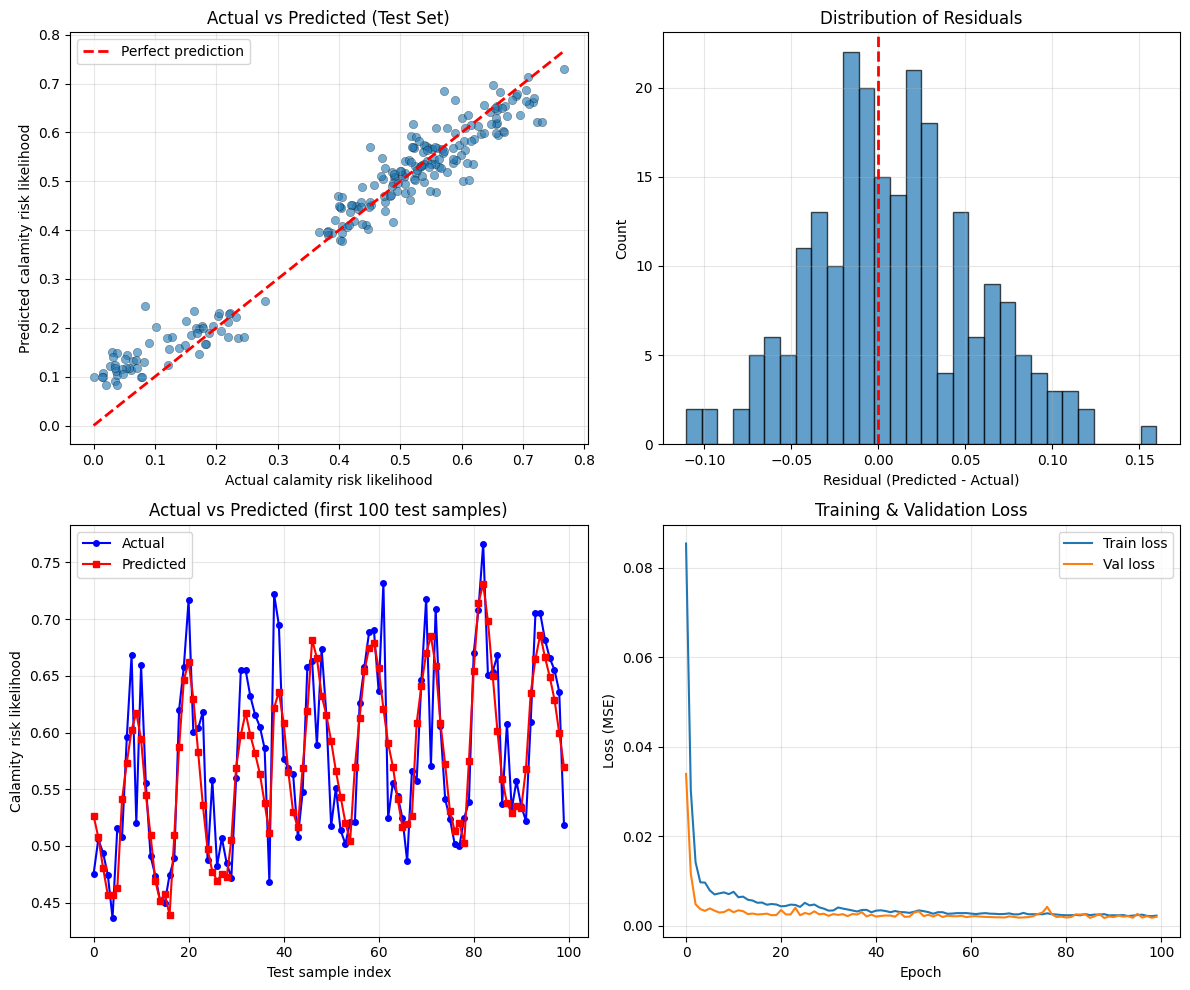

In [16]:
# Evaluation: MAE, RMSE, R² and visualizations
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on test set (model outputs scaled values)
y_pred_scaled = lstm_model.predict(X_test, verbose=0)
y_pred_scaled = y_pred_scaled.flatten()

# Inverse transform to original scale for interpretable metrics
y_test_orig = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_orig = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Compute metrics
mae = mean_absolute_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2 = r2_score(y_test_orig, y_pred_orig)

print("=" * 50)
print("Test Set Evaluation (original scale)")
print("=" * 50)
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print("=" * 50)
print("\nInterpretation:")
print("  • Lower MAE/RMSE = better predictions.")
print("  • R² close to 1 = model explains variance well; R² < 0 = worse than predicting the mean.")

# --- Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Actual vs Predicted (scatter)
ax1 = axes[0, 0]
ax1.scatter(y_test_orig, y_pred_orig, alpha=0.6, edgecolors="k", linewidth=0.3)
min_val = min(y_test_orig.min(), y_pred_orig.min())
max_val = max(y_test_orig.max(), y_pred_orig.max())
ax1.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect prediction")
ax1.set_xlabel("Actual calamity risk likelihood")
ax1.set_ylabel("Predicted calamity risk likelihood")
ax1.set_title("Actual vs Predicted (Test Set)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Residuals (predicted - actual)
ax2 = axes[0, 1]
residuals = y_pred_orig - y_test_orig
ax2.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
ax2.axvline(0, color="red", linestyle="--", linewidth=2)
ax2.set_xlabel("Residual (Predicted - Actual)")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of Residuals")
ax2.grid(True, alpha=0.3)

# 3. Predictions over sample index (first 100 test points)
ax3 = axes[1, 0]
n_show = min(100, len(y_test_orig))
ax3.plot(range(n_show), y_test_orig[:n_show], "b-o", label="Actual", markersize=4)
ax3.plot(range(n_show), y_pred_orig[:n_show], "r-s", label="Predicted", markersize=4)
ax3.set_xlabel("Test sample index")
ax3.set_ylabel("Calamity risk likelihood")
ax3.set_title("Actual vs Predicted (first 100 test samples)")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Training history (loss and val_loss if available)
ax4 = axes[1, 1]
if "history" in dir() and history is not None:
    ax4.plot(history.history["loss"], label="Train loss")
    ax4.plot(history.history["val_loss"], label="Val loss")
    ax4.set_xlabel("Epoch")
    ax4.set_ylabel("Loss (MSE)")
    ax4.set_title("Training & Validation Loss")
    ax4.legend()
else:
    ax4.text(0.5, 0.5, "Training history not available", ha="center", va="center", transform=ax4.transAxes)
    ax4.set_title("Training & Validation Loss")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Save Model and Scalers for Web App Integration

Save all necessary artifacts for deployment:
- Trained LSTM model
- Feature scaler
- Target scaler
- Feature column names

In [ ]:
# Save all artifacts needed for the web app
import json
import joblib

# Directory for saved artifacts (use BASE_PATH from earlier in notebook)
SAVE_DIR = BASE_PATH / 'model_artifacts'
SAVE_DIR.mkdir(exist_ok=True)

# 1. Save the trained LSTM model (Keras format for easy load in backend)
lstm_model.save(SAVE_DIR / 'lstm_calamity_model.keras')
print(f"Saved: {SAVE_DIR / 'lstm_calamity_model.keras'}")

# 2. Save feature scaler (scale inputs before feeding to model)
joblib.dump(feature_scaler, SAVE_DIR / 'feature_scaler.joblib')
print(f"Saved: {SAVE_DIR / 'feature_scaler.joblib'}")

# 3. Save target scaler (inverse-transform model output to get risk in original scale)
joblib.dump(target_scaler, SAVE_DIR / 'target_scaler.joblib')
print(f"Saved: {SAVE_DIR / 'target_scaler.joblib'}")

# 4. Save config for web app (feature names, sequence length, target name)
config = {
    'feature_cols': feature_cols,
    'sequence_length': int(sequence_length),
    'target_col': target_col,
    'n_features': len(feature_cols),
}
with open(SAVE_DIR / 'model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f"Saved: {SAVE_DIR / 'model_config.json'}")

print("\nAll artifacts saved to:", SAVE_DIR)
print("In your web app, load: lstm_calamity_model.keras, feature_scaler.joblib, target_scaler.joblib, model_config.json")

Saved: d:\Users\Vince Joseph\Downloads-New\Hazard\model_artifacts\lstm_calamity_model.keras
Saved: d:\Users\Vince Joseph\Downloads-New\Hazard\model_artifacts\feature_scaler.joblib
Saved: d:\Users\Vince Joseph\Downloads-New\Hazard\model_artifacts\target_scaler.joblib
Saved: d:\Users\Vince Joseph\Downloads-New\Hazard\model_artifacts\model_config.json

All artifacts saved to: d:\Users\Vince Joseph\Downloads-New\Hazard\model_artifacts
In your web app, load: lstm_calamity_model.keras, feature_scaler.joblib, target_scaler.joblib, model_config.json
